In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_preprocessing_problems_60k.csv to customer_churn_preprocessing_problems_60k (2).csv


## Dataset Column Description

This dataset contains customer information used to study customer behavior and predict customer churn.

| Column | Description |
|---|---|
| **Customer_ID** | A unique identification number assigned to each customer. |
| **Age** | The age of the customer in years. |
| **Monthly_Income** | The customer's estimated monthly income. |
| **Credit_Score** | A numerical score representing the customer's creditworthiness. |
| **City** | The city where the customer lives. |
| **Gender** | The gender of the customer. |
| **Contract_Type** | The type of service contract selected by the customer, such as monthly, one-year, or two-year. |
| **Satisfaction_Level** | The customer's level of satisfaction with the service, such as Low, Medium, or High. |
| **Tenure_Months** | The number of months the customer has been using the company's service. |
| **Monthly_Usage_GB** | The amount of data used by the customer per month, measured in gigabytes (GB). |
| **Avg_Session_Minutes** | The average duration of a customer's service session, measured in minutes. |
| **Support_Calls** | The number of times the customer contacted customer support. |
| **Application_Date** | The date when the customer registered or started using the service. |
| **Economic_Index** | A numerical indicator representing the economic conditions associated with the customer at the time of registration. |
| **Promo_Code** | The promotional or discount code used by the customer, if any. |
| **Churned** | The target variable indicating whether the customer left the company. `0` means the customer stayed, while `1` means the customer churned. |


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv(r"customer_churn_preprocessing_problems_60k.csv")
df.head()

,Customer_ID,Age,Monthly_Income,Credit_Score,City,Gender,Contract_Type,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,Promo_Code,Churned
0,112629,49,6303.75,733.1,NaN,Male,One year,Medium,21.0,86.18,31.28,3.0,2024-04-15,106.50,NaN,0
1,137731,18,11778.13,647.9,ALEXANDRIA,female,One year,High,9.0,19.87,66.82,0.0,Jun 14 2024,105.25,NaN,0
2,139992,60,11371.69,608.4,Giza,Female,Month-to-month,High,42.0,23.92,91.58,2.0,Jan 22 2024,102.88,NaN,0
3,108526,35,21656.24,799.2,Giza,Female,Month-to-month,High,64.0,56.71,41.96,2.0,NaN,101.29,NaN,0
4,108280,44,11929.67,480.5,Alexandria,Female,One year,Medium,12.0,24.32,47.00,1.0,12/30/2025,102.30,VIP,0


In [4]:
df.shape

(60000, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          60000 non-null  int64  
 1   Age                  58521 non-null  object 
 2   Monthly_Income       57908 non-null  float64
 3   Credit_Score         58806 non-null  float64
 4   City                 58800 non-null  object 
 5   Gender               59281 non-null  object 
 6   Contract_Type        58918 non-null  object 
 7   Satisfaction_Level   58803 non-null  object 
 8   Tenure_Months        59102 non-null  float64
 9   Monthly_Usage_GB     58804 non-null  float64
 10  Avg_Session_Minutes  59098 non-null  float64
 11  Support_Calls        59401 non-null  float64
 12  Application_Date     58931 non-null  object 
 13  Economic_Index       58325 non-null  float64
 14  Promo_Code           5996 non-null   object 
 15  Churned              60000 non-null 

In [6]:
df.describe()

,Customer_ID,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
count,60000.000000,57908.000000,58806.000000,59102.000000,58804.000000,59098.000000,59401.000000,58325.000000,60000.000000
mean,129870.806500,15200.117263,655.109298,30.569828,53.181546,47.480746,2.207656,104.481224,0.084567
std,17247.466941,14114.025532,76.372733,18.041173,39.632115,16.074360,1.494984,1.878070,0.278238
min,100001.000000,2500.000000,120.000000,1.000000,2.000000,5.000000,0.000000,98.830000,0.000000
25%,114929.750000,7715.220000,604.725000,17.000000,26.330000,38.390000,1.000000,103.050000,0.000000
50%,129865.500000,11937.890000,655.300000,27.000000,44.820000,47.080000,2.000000,104.510000,0.000000
75%,144804.250000,18658.387500,706.000000,42.000000,70.610000,55.770000,3.000000,105.940000,0.000000
max,159750.000000,815730.181611,980.000000,72.000000,1278.219002,299.795362,10.000000,110.400000,1.000000


In [7]:
object_data = df.select_dtypes(include="object")

print("Object Columns:")
print(object_data.columns.tolist())

object_data.head()

Object Columns:
['Age', 'City', 'Gender', 'Contract_Type', 'Satisfaction_Level', 'Application_Date', 'Promo_Code']


,Age,City,Gender,Contract_Type,Satisfaction_Level,Application_Date,Promo_Code
0,49,NaN,Male,One year,Medium,2024-04-15,NaN
1,18,ALEXANDRIA,female,One year,High,Jun 14 2024,NaN
2,60,Giza,Female,Month-to-month,High,Jan 22 2024,NaN
3,35,Giza,Female,Month-to-month,High,NaN,NaN
4,44,Alexandria,Female,One year,Medium,12/30/2025,VIP


In [8]:
misssing_raw = df.isna().sum().to_frame("MIssing_Count")
misssing_raw["Missing_%"] = (df.isna().mean() * 100).round(2)

misssing_raw.sort_values("Missing_%", ascending=False)

,MIssing_Count,Missing_%
Promo_Code,54004,90.01
Monthly_Income,2092,3.49
Economic_Index,1675,2.79
Age,1479,2.46
Satisfaction_Level,1197,2.00
City,1200,2.00
Credit_Score,1194,1.99
Monthly_Usage_GB,1196,1.99
Contract_Type,1082,1.80
Application_Date,1069,1.78


In [9]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 250


In [10]:
print("Count:")
print(df["Churned"].value_counts())

print("\nPercent:")
print((df["Churned"].value_counts(normalize=True)*100).round(2))

Count:
Churned
0    54926
1     5074
Name: count, dtype: int64

Percent:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64


In [11]:
print("Before removing duplicates:", len(df))

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", len(df))

Before removing duplicates: 60000
After removing duplicates: 59750


In [12]:
# Age is saved as str
df["Age"]= pd.to_numeric(df["Age"],errors="coerce")

In [13]:
df.describe()

,Customer_ID,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
count,59750.000000,57563.000000,57665.000000,58558.000000,58854.000000,58557.000000,58856.000000,59153.000000,58086.000000,59750.000000
mean,129875.500000,39.237566,15192.509436,655.114090,30.563972,53.183831,47.470550,2.207462,104.481015,0.084569
std,17248.483629,12.047459,14117.352402,76.393889,18.037092,39.648415,16.047074,1.494829,1.878239,0.278242
min,100001.000000,-5.000000,2500.000000,120.000000,1.000000,2.000000,5.000000,0.000000,98.830000,0.000000
25%,114938.250000,31.000000,7711.550000,604.800000,17.000000,26.330000,38.390000,1.000000,103.050000,0.000000
50%,129875.500000,39.000000,11933.590000,655.300000,27.000000,44.830000,47.070000,2.000000,104.510000,0.000000
75%,144812.750000,47.000000,18650.590000,706.100000,42.000000,70.610000,55.760000,3.000000,105.940000,0.000000
max,159750.000000,150.000000,815730.181611,980.000000,72.000000,1278.219002,299.795362,10.000000,110.400000,1.000000


In [14]:
# Age values are logically incorrect
df.loc[~df["Age"].between(18,90),"Age"]=np.nan

In [15]:
df.loc[~df["Credit_Score"].between(300, 850), "Credit_Score"] = np.nan

In [16]:
df.describe()

,Customer_ID,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
count,59750.000000,57473.000000,57665.000000,58478.000000,58854.000000,58557.000000,58856.000000,59153.000000,58086.000000,59750.000000
mean,129875.500000,39.185478,15192.509436,655.257890,30.563972,53.183831,47.470550,2.207462,104.481015,0.084569
std,17248.483629,11.585664,14117.352402,74.672082,18.037092,39.648415,16.047074,1.494829,1.878239,0.278242
min,100001.000000,18.000000,2500.000000,300.000000,1.000000,2.000000,5.000000,0.000000,98.830000,0.000000
25%,114938.250000,31.000000,7711.550000,604.900000,17.000000,26.330000,38.390000,1.000000,103.050000,0.000000
50%,129875.500000,39.000000,11933.590000,655.300000,27.000000,44.830000,47.070000,2.000000,104.510000,0.000000
75%,144812.750000,47.000000,18650.590000,706.000000,42.000000,70.610000,55.760000,3.000000,105.940000,0.000000
max,159750.000000,75.000000,815730.181611,850.000000,72.000000,1278.219002,299.795362,10.000000,110.400000,1.000000


In [17]:
# Standzrize categorical text

text_cols = ["City", "Gender", "Contract_Type", "Satisfaction_Level"]
for col in text_cols:
  df[col]=df[col].str.strip().str.lower()
  print("\n",col)
  print(df[col].value_counts(dropna=False).head())


 City
City
cairo         24602
giza          11535
alexandria    10730
mansoura       7006
aswan          4682
Name: count, dtype: int64

 Gender
Gender
male      30862
female    28171
NaN         717
Name: count, dtype: int64

 Contract_Type
Contract_Type
month-to-month    34084
one year          14644
two year           9947
NaN                1075
Name: count, dtype: int64

 Satisfaction_Level
Satisfaction_Level
medium    26454
high      17535
low       14566
NaN        1195
Name: count, dtype: int64


In [18]:
print(df['Application_Date'].head())

0     2024-04-15
1    Jun 14 2024
2    Jan 22 2024
3            NaN
4     12/30/2025
Name: Application_Date, dtype: object


In [19]:
# Date-Time conversion
df['Application_Date'] = pd.to_datetime(df['Application_Date'],format="mixed",errors="coerce")

In [20]:
print(df['Application_Date'].head())

0   2024-04-15
1   2024-06-14
2   2024-01-22
3          NaT
4   2025-12-30
Name: Application_Date, dtype: datetime64[ns]


In [21]:
print("\nMissing dates:", df['Application_Date'].isna().sum())


Missing dates: 1424


In [22]:
print("Rows before removal:", len(df))

df = df.dropna(subset=["Application_Date"]).reset_index(drop=True)

print("Rows after removal:", len(df))

Rows before removal: 59750
Rows after removal: 58326


**EDA**

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58326 entries, 0 to 58325
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer_ID          58326 non-null  int64         
 1   Age                  56099 non-null  float64       
 2   Monthly_Income       56288 non-null  float64       
 3   Credit_Score         57085 non-null  float64       
 4   City                 57160 non-null  object        
 5   Gender               57622 non-null  object        
 6   Contract_Type        57278 non-null  object        
 7   Satisfaction_Level   57156 non-null  object        
 8   Tenure_Months        57459 non-null  float64       
 9   Monthly_Usage_GB     57158 non-null  float64       
 10  Avg_Session_Minutes  57457 non-null  float64       
 11  Support_Calls        57744 non-null  float64       
 12  Application_Date     58326 non-null  datetime64[ns]
 13  Economic_Index       56696 non-

In [24]:
df.describe()

,Customer_ID,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,Churned
count,58326.000000,56099.000000,56288.000000,57085.000000,57459.000000,57158.000000,57457.000000,57744.000000,58326,56696.000000,58326.000000
mean,129883.863063,39.179201,15189.950818,655.208331,30.576011,53.186202,47.458366,2.209061,2025-04-15 06:12:19.923876352,104.480398,0.084611
min,100001.000000,18.000000,2500.000000,300.000000,1.000000,2.000000,5.000000,0.000000,2024-01-01 00:00:00,98.830000,0.000000
25%,114944.250000,31.000000,7716.207500,604.800000,17.000000,26.350000,38.390000,1.000000,2024-08-23 00:00:00,103.040000,0.000000
50%,129887.500000,39.000000,11931.780000,655.200000,27.000000,44.830000,47.080000,2.000000,2025-04-15 00:00:00,104.510000,0.000000
75%,144819.750000,47.000000,18642.087500,705.900000,42.000000,70.560000,55.760000,3.000000,2025-12-08 00:00:00,105.940000,0.000000
max,159750.000000,75.000000,815730.181611,850.000000,72.000000,1278.219002,299.795362,10.000000,2026-07-31 00:00:00,110.400000,1.000000
std,17249.426201,11.575935,14136.182792,74.671384,18.041863,39.715731,15.921551,1.495285,NaN,1.878869,0.278304


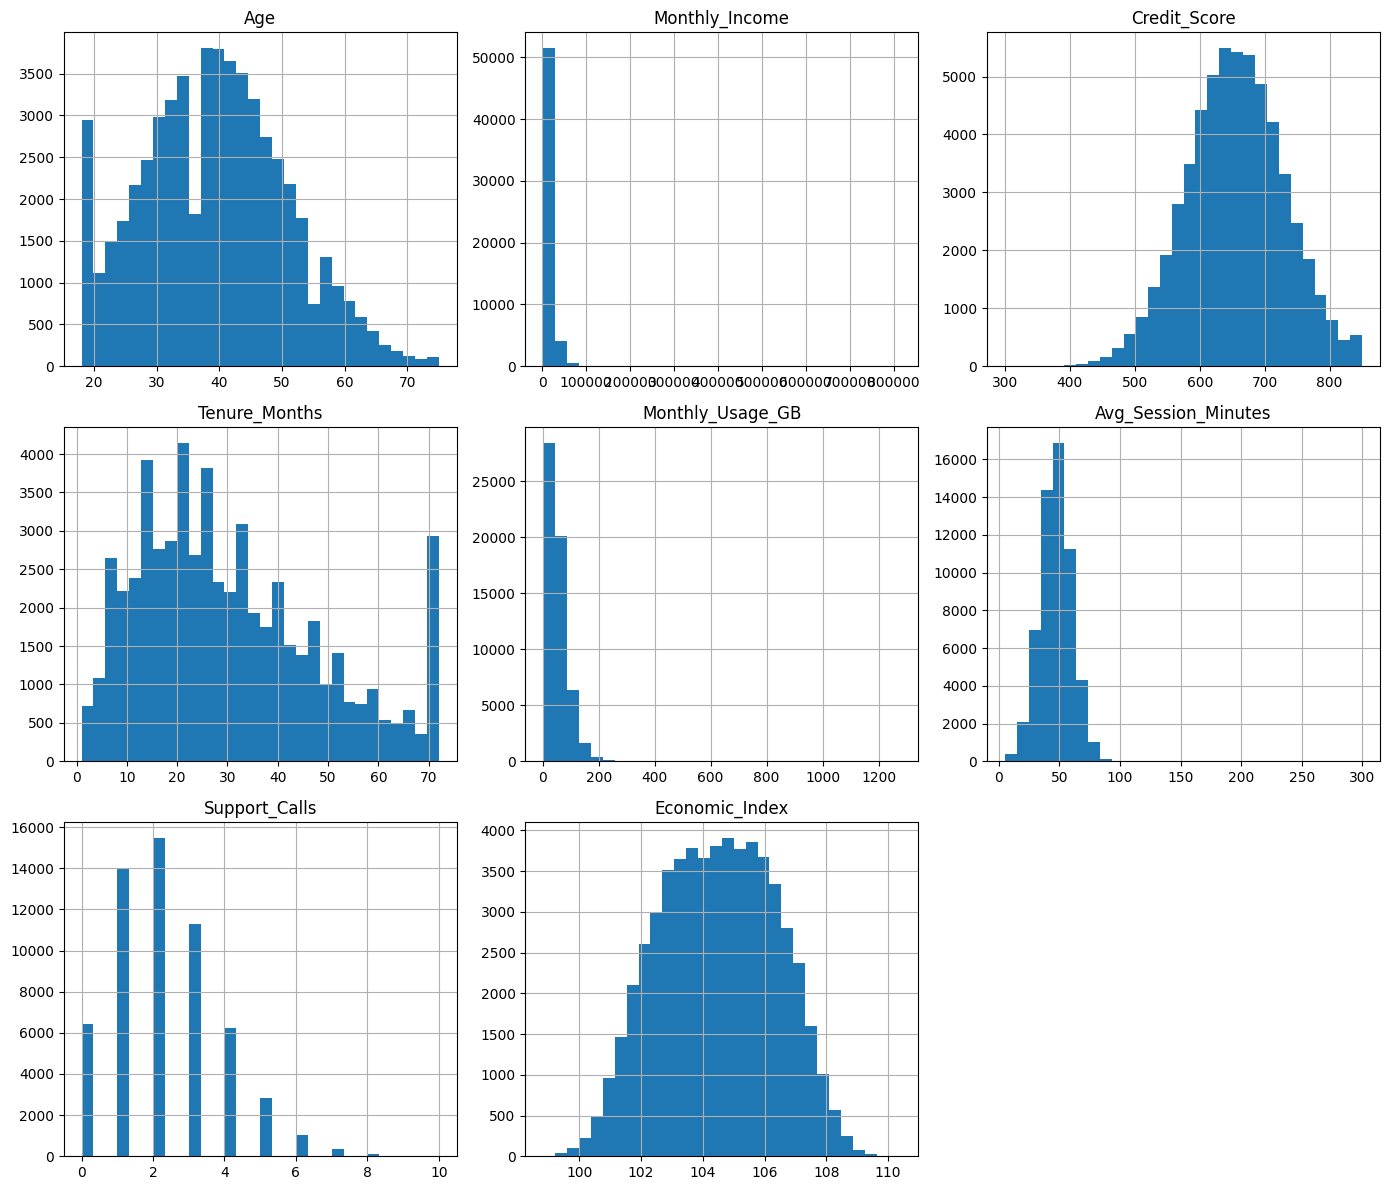

In [25]:
numeric_cols = df.select_dtypes(include="number").columns

numeric_cols = numeric_cols.drop(["Churned", "Customer_ID"], errors="ignore")

df[numeric_cols].hist(figsize=(14, 12), bins=30)

plt.tight_layout()
plt.show()

In [26]:
# Skewness check

df[numeric_cols].skew().round(3).sort_values(key=abs, ascending=False)

# sort for most skewd to less one
# near to 0 will be symmetrc
# from 0.5 to 1 or from -0.5 to -1 will be moderate skew
# more than 1 or less than -1 will be strong skeew


,0
Monthly_Income,11.241
Avg_Session_Minutes,4.284
Monthly_Usage_GB,3.881
Support_Calls,0.680
Tenure_Months,0.677
Age,0.191
Economic_Index,-0.038
Credit_Score,-0.028


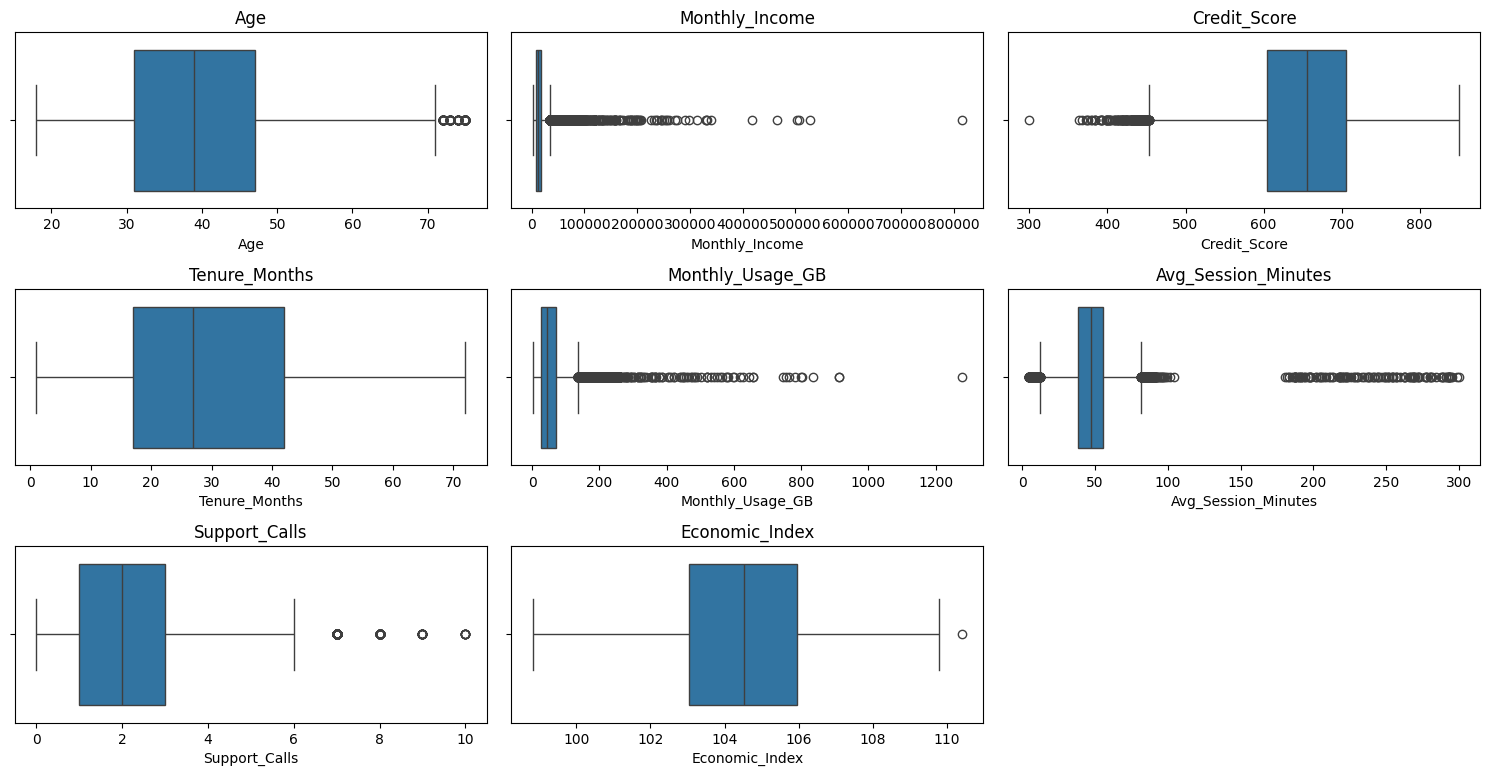

In [27]:
# Cheching possible outliers

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [28]:
categorical_cols_eda = df.select_dtypes(include="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols_eda)

for col in categorical_cols_eda:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


Categorical Columns:
['City', 'Gender', 'Contract_Type', 'Satisfaction_Level', 'Promo_Code']

 City
City
cairo         24013
giza          11261
alexandria    10469
mansoura       6825
aswan          4592
NaN            1166
Name: count, dtype: int64

 Gender
Gender
male      30107
female    27515
NaN         704
Name: count, dtype: int64

 Contract_Type
Contract_Type
month-to-month    33273
one year          14292
two year           9713
NaN                1048
Name: count, dtype: int64

 Satisfaction_Level
Satisfaction_Level
medium    25808
high      17120
low       14228
NaN        1170
Name: count, dtype: int64

 Promo_Code
Promo_Code
NaN    52498
P20     1979
P10     1933
VIP     1916
Name: count, dtype: int64


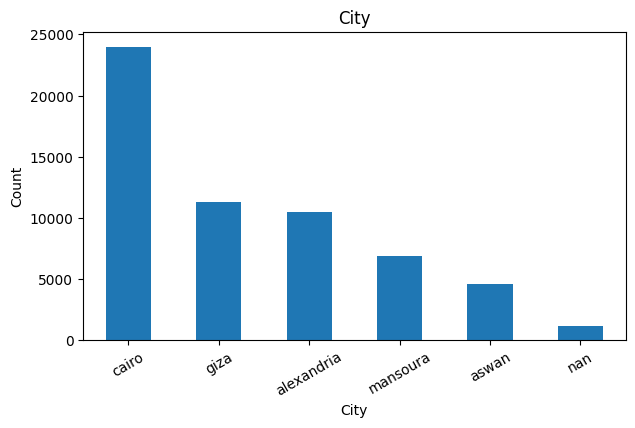

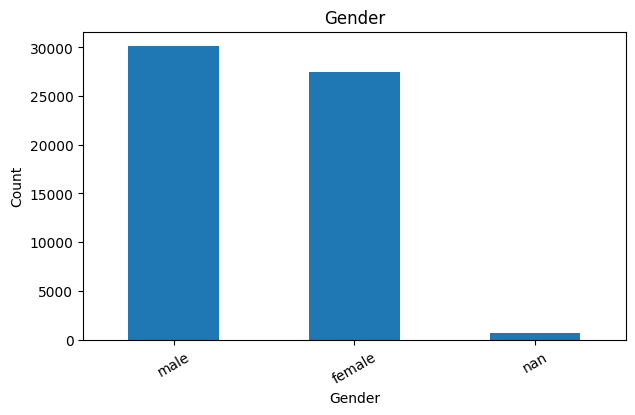

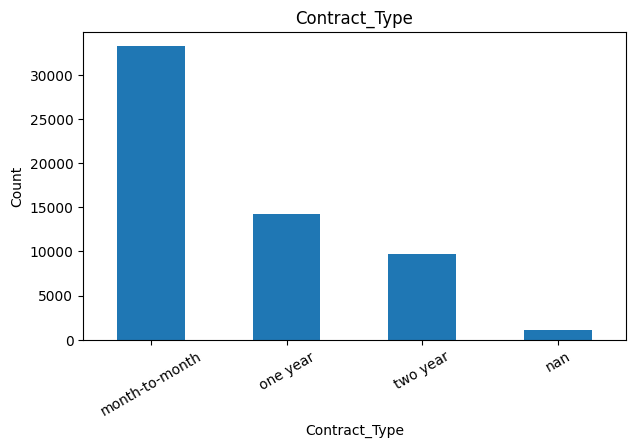

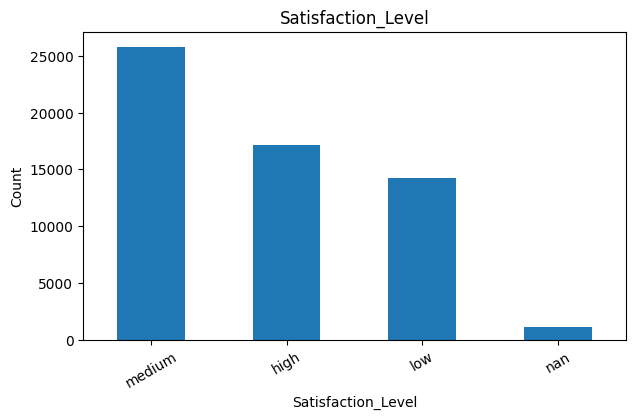

In [29]:
categorical_plot_cols = ["City", "Gender", "Contract_Type", "Satisfaction_Level"]

for col in categorical_plot_cols:
    df[col].value_counts(dropna=False).plot(kind="bar", figsize=(7, 4))
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()


In [30]:
# Correlation

corr_cols = numeric_cols.tolist() + ["Churned"]

correleation = df[corr_cols].corr().round(2)
correleation

,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
Age,1.00,-0.00,-0.0,0.00,0.00,0.00,-0.01,-0.0,-0.02
Monthly_Income,-0.00,1.00,0.0,0.00,-0.00,0.00,0.00,0.0,-0.01
Credit_Score,-0.00,0.00,1.0,0.00,0.00,-0.00,-0.00,0.0,0.00
Tenure_Months,0.00,0.00,0.0,1.00,0.00,0.00,0.00,-0.0,-0.03
Monthly_Usage_GB,0.00,-0.00,0.0,0.00,1.00,0.00,-0.00,0.0,0.02
Avg_Session_Minutes,0.00,0.00,-0.0,0.00,0.00,1.00,-0.01,0.0,-0.00
Support_Calls,-0.01,0.00,-0.0,0.00,-0.00,-0.01,1.00,0.0,0.04
Economic_Index,-0.00,0.00,0.0,-0.00,0.00,0.00,0.00,1.0,-0.00
Churned,-0.02,-0.01,0.0,-0.03,0.02,-0.00,0.04,-0.0,1.00


**Date time Exploration**

In [31]:
print("First date", df['Application_Date'].min())
print("Last date", df['Application_Date'].max())

First date 2024-01-01 00:00:00
Last date 2026-07-31 00:00:00


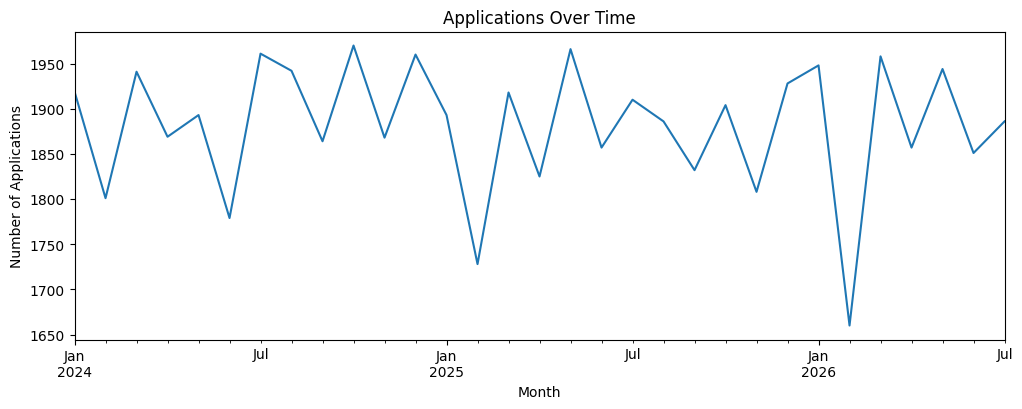

In [32]:
application_by_month = df.groupby(
    df["Application_Date"].dt.to_period("M")
).size()

application_by_month.plot(figsize=(12, 4))
plt.title("Applications Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.show()

**Split**

In [33]:
X = df.drop(columns=["Customer_ID", "Churned"])
y = df["Churned"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain class %:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class %:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train: (46660, 14)
Test: (11666, 14)

Train class %:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64

Test class %:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64


In [35]:
missing_train = X_train.isna().sum().to_frame("Missing_Count")

missing_train["Missing_%"] = (X_train.isna().mean() * 100).round(2)

missing_train["Data_Type"] = X_train.dtypes.astype(str)

missing_train.sort_values("Missing_%", ascending=False)

,Missing_Count,Missing_%,Data_Type
Promo_Code,42024,90.06,object
Age,1770,3.79,float64
Monthly_Income,1661,3.56,float64
Economic_Index,1310,2.81,float64
Credit_Score,1003,2.15,float64
Monthly_Usage_GB,958,2.05,float64
City,928,1.99,object
Satisfaction_Level,911,1.95,object
Contract_Type,810,1.74,object
Avg_Session_Minutes,704,1.51,float64


### Missing-value decisions for this dataset

| Column | Decision | Why |
|---|---|---|
| Promo_Code | Drop column | About 90% missing |
| Economic_Index | Ordered fill | Values change with datetime order |
| Age | Mean | Approximately symmetric |
| Credit_Score | Mean | Approximately symmetric and bounded |
| Monthly_Income | Median | Strong right skew |
| Monthly_Usage_GB | Median | Strong right skew |
| Avg_Session_Minutes | Median | Strong right skew |
| Tenure_Months | Median | Right-skewed |
| Support_Calls | Median | Discrete count with right tail |
| City | `unknown` | Avoid inventing a city |
| Gender | `unknown` | Avoid inventing a category |
| Contract_Type | Train mode | Reasonable classroom choice |
| Satisfaction_Level | Train mode | Reasonable classroom choice |

In [36]:
X_train = X_train.drop(columns="Promo_Code")
X_test = X_test.drop(columns="Promo_Code")

In [37]:
train_sorted = X_train.sort_values("Application_Date")
test_sorted = X_test.sort_values("Application_Date")

X_train["Economic_Index"] = train_sorted["Economic_Index"].ffill().bfill()
X_test["Economic_Index"] = test_sorted["Economic_Index"].ffill().bfill()

print("Train missing Economic_Index:", X_train["Economic_Index"].isna().sum())
print("Test missing Economic_Index :", X_test["Economic_Index"].isna().sum())


Train missing Economic_Index: 0
Test missing Economic_Index : 0


In [38]:
numeric_missing = [
    "Age", "Monthly_Income", "Credit_Score", "Tenure_Months",
    "Monthly_Usage_GB", "Avg_Session_Minutes", "Support_Calls"
]

print("Missing values:")
print(X_train[numeric_missing].isna().sum())


print("\nSkewness:")
print(X_train[numeric_missing].skew().round(3))

Missing values:
Age                    1770
Monthly_Income         1661
Credit_Score           1003
Tenure_Months           674
Monthly_Usage_GB        958
Avg_Session_Minutes     704
Support_Calls           464
dtype: int64

Skewness:
Age                    0.194
Monthly_Income         9.337
Credit_Score          -0.027
Tenure_Months          0.675
Monthly_Usage_GB       3.784
Avg_Session_Minutes    4.284
Support_Calls          0.676
dtype: float64


In [39]:
for col in ["Age", "Credit_Score"]:
  value = X_train[col].mean()
  X_train[col] = X_train[col].fillna(value)
  X_test[col] = X_test[col].fillna(value)

In [40]:
median_cols = [
    "Monthly_Income", "Tenure_Months", "Monthly_Usage_GB",
    "Avg_Session_Minutes", "Support_Calls"
]

for col in median_cols:
  value = X_train[col].median()
  X_train[col] = X_train[col].fillna(value)
  X_test[col] = X_test[col].fillna(value)

In [41]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
  print("\n", col)
  print(X_train[col].value_counts(dropna=False).head())


 City
City
cairo         19277
giza           8961
alexandria     8392
mansoura       5445
aswan          3657
Name: count, dtype: int64

 Gender
Gender
male      24129
female    21969
NaN         562
Name: count, dtype: int64

 Contract_Type
Contract_Type
month-to-month    26620
one year          11507
two year           7723
NaN                 810
Name: count, dtype: int64

 Satisfaction_Level
Satisfaction_Level
medium    20675
high      13720
low       11354
NaN         911
Name: count, dtype: int64


In [42]:
X_train["City"] = X_train["City"].fillna("unknown")
X_test["City"] = X_test["City"].fillna("unknown")

In [43]:
X_train["Gender"] = X_train["Gender"].fillna("unknown")
X_test["Gender"] = X_test["Gender"].fillna("unknown")

In [44]:
for col in ["Contract_Type", "Satisfaction_Level"]:
  value = X_train[col].mode()[0]
  X_train[col] = X_train[col].fillna(value)
  X_test[col] = X_test[col].fillna(value)

In [45]:
numeric_check_cols = [
    "Age", "Monthly_Income", "Credit_Score", "Tenure_Months",
    "Monthly_Usage_GB", "Avg_Session_Minutes", "Support_Calls",
    "Economic_Index"
]

for col in numeric_check_cols:
    data = X_train[col]

    q1 = data.quantile(0.25) #25%
    q3 = data.quantile(0.75) #75%
    iqr = q3 - q1 #50%
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outliers = ((data < lower) | (data > upper)).sum()
    #--------------------------------------------------------------
    z = ((data - data.mean()) / data.std()).abs() # x-mean/std
    z_outliers = (z > 3).sum()

    print("\n", col)
    print("Skewness:", round(data.skew(), 3))
    print("IQR outliers:", iqr_outliers)
    print("Z > 3:", z_outliers)
    print("Min:", round(data.min(), 2))
    print("Max:", round(data.max(), 2))



 Age
Skewness: 0.198
IQR outliers: 148
Z > 3: 76
Min: 18.0
Max: 75.0

 Monthly_Income
Skewness: 9.505
IQR outliers: 2617
Z > 3: 542
Min: 2500.0
Max: 526856.44

 Credit_Score
Skewness: -0.028
IQR outliers: 187
Z > 3: 59
Min: 300.0
Max: 850.0

 Tenure_Months
Skewness: 0.688
IQR outliers: 0
Z > 3: 0
Min: 1.0
Max: 72.0

 Monthly_Usage_GB
Skewness: 3.831
IQR outliers: 1519
Z > 3: 517
Min: 2.0
Max: 1278.22

 Avg_Session_Minutes
Skewness: 4.317
IQR outliers: 527
Z > 3: 115
Min: 5.0
Max: 299.8

 Support_Calls
Skewness: 0.683
IQR outliers: 352
Z > 3: 352
Min: 0.0
Max: 10.0

 Economic_Index
Skewness: -0.037
IQR outliers: 1
Z > 3: 2
Min: 98.83
Max: 110.4


### Outlier decision for each numerical column

| Column | Decision | Reason |
|---|---|---|
| Age | Keep | Remaining values are valid ages; IQR flags do not automatically mean errors |
| Monthly_Income | IQR capping | Strong right skew and many extreme values |
| Credit_Score | Keep | Already domain-bounded; valid extremes can remain |
| Tenure_Months | Keep | No meaningful extreme problem |
| Monthly_Usage_GB | IQR capping | Strong right skew |
| Avg_Session_Minutes | IQR capping | Strong right skew |
| Support_Calls | Keep | Valid discrete count data |
| Economic_Index | Z-score capping | Approximately symmetric |


In [46]:
iqr_cols = ["Monthly_Income", "Monthly_Usage_GB", "Avg_Session_Minutes"]

for col in iqr_cols:
  q1 = X_train[col].quantile(0.25)
  q2 = X_train[col].quantile(0.25)
  iqr = q3 - q1

  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr

  print(col, "limits:", round(lower, 2), "to", round(upper, 2))

  X_train[col] = X_train[col].clip(lower, upper)
  X_test[col] = X_test[col].clip(lower, upper)

Monthly_Income limits: 19471.56 to -11513.45
Monthly_Usage_GB limits: -91.92 to 224.64
Avg_Session_Minutes limits: -62.55 to 207.02


In [47]:
mean = X_train['Economic_Index'].mean()
std = X_train['Economic_Index'].std()

z = ((X_train['Economic_Index'] - mean) / std).abs()
print("Economic index values with z > 3:", (z > 3).sum())

lower = mean - 3 * std
upper = mean + 3 * std

X_train["Economic_Index"] = X_train["Economic_Index"].clip(lower, upper)
X_test["Economic_Index"] = X_test["Economic_Index"].clip(lower, upper)

print("Z-score limits:", round(lower, 2), "to", round(upper, 2))

Economic index values with z > 3: 2
Z-score limits: 98.85 to 110.11


**Encoding**

| Column | Type | Encoding |
|---|---|---|
| Satisfaction_Level | Ordinal | Ordered mapping |
| City | Nominal | One-Hot Encoding |
| Gender | Nominal | One-Hot Encoding |
| Contract_Type | Nominal | One-Hot Encoding |

In [48]:
satisfaction_order = {
    "low":0,
    "medium":1,
    "high":2
}

X_train["Satisfaction_Level"] = X_train["Satisfaction_Level"].map(satisfaction_order)
X_test["Satisfaction_Level"] = X_test["Satisfaction_Level"].map(satisfaction_order)

X_train['Satisfaction_Level'].value_counts().sort_index()

,count
Satisfaction_Level,
0,11354
1,21586
2,13720


In [49]:
nominal_cols = ["City", "Gender", "Contract_Type"]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
).set_output(transform="pandas")

train_encoded = encoder.fit_transform(X_train[nominal_cols])
test_encoded = encoder.transform(X_test[nominal_cols])

X_train = pd.concat(
    [X_train.drop(columns=nominal_cols), train_encoded],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=nominal_cols), test_encoded],
    axis=1
)

print("Encoded columns:")
print(train_encoded.columns.tolist())

Encoded columns:
['City_alexandria', 'City_aswan', 'City_cairo', 'City_giza', 'City_mansoura', 'City_unknown', 'Gender_female', 'Gender_male', 'Gender_unknown', 'Contract_Type_month-to-month', 'Contract_Type_one year', 'Contract_Type_two year']


**Scaling**

In [50]:
robust_cols = [
    "Monthly_Income", "Monthly_Usage_GB", "Avg_Session_Minutes"
]

standard_cols = [
    "Age", "Credit_Score", "Tenure_Months", "Support_Calls", "Economic_Index"
]

robust_scaler = RobustScaler()
X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

standard_scaler = StandardScaler()
X_train[standard_cols] = robust_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = robust_scaler.transform(X_test[standard_cols])

In [51]:
X_train.head()

,Age,Monthly_Income,Credit_Score,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,City_alexandria,City_aswan,City_cairo,City_giza,City_mansoura,City_unknown,Gender_female,Gender_male,Gender_unknown,Contract_Type_month-to-month,Contract_Type_one year,Contract_Type_two year
14773,0.000000,-0.002415,-0.546050,0,-0.12,0.487680,0.940281,0.5,2024-10-16,-0.770833,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
42415,-0.698985,0.720378,0.400306,2,0.04,-0.574642,-0.649883,0.0,2025-10-02,0.361111,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
54029,0.738515,-0.473720,-0.937751,0,1.04,-0.276190,-0.591920,1.0,2024-07-31,-0.159722,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7577,-0.386485,0.334552,0.518727,2,1.36,1.066960,-0.174473,0.0,2025-06-05,0.826389,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
34052,0.051015,0.720378,0.715083,1,-0.64,0.655110,0.406909,2.0,2025-06-26,1.104167,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


**Class** **Imbalance**


In [53]:
print("Original Training distribution:")
print(y_train.value_counts())

print("\nPercent:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Original Training distribution:
Churned
0    42712
1     3948
Name: count, dtype: int64

Percent:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64


In [54]:
# Random Oversampling

ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Shape:", X_train_over.shape)
print(y_train_over.value_counts())

Shape: (85424, 22)
Churned
0    42712
1    42712
Name: count, dtype: int64


In [56]:
# Random Undersampling

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Shape:", X_train_under.shape)
print(y_train_under.value_counts())

Shape: (7896, 22)
Churned
0    3948
1    3948
Name: count, dtype: int64


In [57]:
# SMOTE sampling

X_train = X_train.drop(columns=["Application_Date"])
X_test = X_test.drop(columns=["Application_Date"])

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Shape:", X_train_smote.shape)
print(y_train_smote.value_counts())

Shape: (85424, 21)
Churned
0    42712
1    42712
Name: count, dtype: int64
